# Khám Phá Dữ Liệu (EDA) - Pima Indians Diabetes

**Bài toán:** Phân loại nhị phân — dự đoán khả năng mắc bệnh tiểu đường.

**Bộ dữ liệu:** `pima-indians-diabetes.csv` — gồm 768 mẫu, 8 đặc trưng số và 1 nhãn nhị phân (0: không mắc, 1: mắc bệnh).

**Mục tiêu notebook này:**
- Tìm hiểu cấu trúc và chất lượng dữ liệu thô.
- Phát hiện các vấn đề tiềm ẩn (giá trị 0 bất hợp lý, mất cân bằng lớp, phân phối lệch).
- Chia train/test và chuẩn hoá dữ liệu, xuất ra các file CSV dùng chung cho notebook train và test.


# 1. Định Nghĩa Vấn Đề

Bộ dữ liệu Pima Indians Diabetes ghi nhận các chỉ số y tế của phụ nữ người Mỹ bản địa nhóm Pima, với mục tiêu dự đoán liệu bệnh nhân có mắc tiểu đường hay không dựa trên các đặc trưng lâm sàng.

Ý nghĩa các đặc trưng:
- **Pregnancies** — số lần mang thai.
- **Glucose** — nồng độ glucose huyết tương sau 2 giờ trong bài kiểm tra dung nạp glucose.
- **BloodPressure** — huyết áp tâm trương (mm Hg).
- **SkinThickness** — độ dày nếp gấp da cơ tam đầu (mm).
- **Insulin** — nồng độ insulin huyết thanh 2 giờ (mu U/ml).
- **BMI** — chỉ số khối cơ thể (kg/m²).
- **DiabetesPedigreeFunction** — chỉ số di truyền tiểu đường trong gia đình.
- **Age** — tuổi (năm).
- **class** — nhãn đầu ra: 0 = không mắc, 1 = mắc bệnh tiểu đường.

**Lưu ý:** Các cột Glucose, BloodPressure, SkinThickness, Insulin và BMI có giá trị 0 không hợp lý về mặt sinh lý — đây là giá trị thiếu được mã hoá dưới dạng 0 trong bộ dữ liệu gốc.


# 2. Chuẩn Bị
## 2.1. Khai Báo Thư Viện và Tham Số Thực Nghiệm

Toàn bộ các đường dẫn và siêu tham số được định nghĩa tập trung tại đây để dễ tái sử dụng ở notebook tiếp theo.


In [1]:
import json, os, warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Tham số thực nghiệm ────────────────────────────────────────────────────
DATA_FILE    = 'pima-indians-diabetes.csv'
EXP_NAME     = 'pima_indians_diabetes'
FEATURES     = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
TARGET       = 'class'
RANDOM_STATE = 42
TEST_SIZE    = 0.30

# ── Đường dẫn ──────────────────────────────────────────────────────────────
BASE_DIR = (
    os.path.abspath(os.path.join(os.getcwd(), '..'))
    if os.path.basename(os.getcwd()) == 'prj'
    else os.getcwd()
)
DATA_PATH = os.path.join(BASE_DIR, 'data', DATA_FILE)
EXP_DIR   = os.path.join(BASE_DIR, 'exps_', EXP_NAME)
os.makedirs(EXP_DIR, exist_ok=True)

TRAIN_RAW      = os.path.join(EXP_DIR, 'train_raw.csv')
TEST_RAW       = os.path.join(EXP_DIR, 'test_raw.csv')
TRAIN_MINMAX   = os.path.join(EXP_DIR, 'train_minmax.csv')
TEST_MINMAX    = os.path.join(EXP_DIR, 'test_minmax.csv')
TRAIN_STANDARD = os.path.join(EXP_DIR, 'train_standard.csv')
TEST_STANDARD  = os.path.join(EXP_DIR, 'test_standard.csv')
EDA_LOG        = os.path.join(EXP_DIR, 'eda_log.xlsx')
SPLIT_META     = os.path.join(EXP_DIR, 'split_metadata.json')

print('Base dir :', BASE_DIR)
print('Exp dir  :', EXP_DIR)


Base dir : D:\final-project-CSTTNT-\indians-diabetes
Exp dir  : D:\final-project-CSTTNT-\indians-diabetes\exps_\pima_indians_diabetes


# 3. Phân Tích Dữ Liệu
## 3.1. Thống Kê Mô Tả
### 3.1.1. Kích Thước, Kiểu Dữ Liệu, Giá Trị Thiếu và Phân Bố Lớp

Bước này kiểm tra tổng thể chất lượng dữ liệu:
- `describe()` cho biết phân phối, min/max, các tứ phân vị của từng đặc trưng.
- Đếm giá trị 0 trên các cột không thể bằng 0 về mặt sinh lý để ước lượng mức độ dữ liệu thiếu.
- Kiểm tra cân bằng lớp — nếu tỉ lệ lệch nhiều sẽ cần cân nhắc oversampling hoặc điều chỉnh trọng số.


In [2]:
# File gốc không có header — gán tên cột thủ công
df = pd.read_csv(DATA_PATH, header=None)
df.columns = FEATURES + [TARGET]

print('Shape:', df.shape)
display(df.head())
df.info()
display(df[FEATURES].describe().round(3))

# Kiểm tra giá trị thiếu (NaN thực sự)
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing_df)
print('Duplicate rows:', int(df.duplicated().sum()))

# Kiểm tra giá trị 0 bất hợp lý — không thể bằng 0 về mặt sinh lý
zero_df = (
    df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0
).sum().reset_index()
zero_df.columns = ['feature', 'zero_count']
zero_df['zero_pct'] = (zero_df['zero_count'] / len(df) * 100).round(2)
display(zero_df)

# Phân bố lớp — kiểm tra mức độ mất cân bằng
class_counts = df[TARGET].value_counts().sort_index()
display(class_counts.to_frame('count'))


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   class                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000


,missing_count,missing_pct
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
class,0,0.0


Duplicate rows: 0


,feature,zero_count,zero_pct
0,Glucose,5,0.65
1,BloodPressure,35,4.56
2,SkinThickness,227,29.56
3,Insulin,374,48.70
4,BMI,11,1.43


,count
class,
0,500
1,268


## 3.2. Trực Quan Hoá Dữ Liệu
### 3.2.1. Biểu Đồ Phân Bố Lớp (Class Distribution)

Hai biểu đồ bên dưới cùng thể hiện mức độ mất cân bằng giữa lớp 0 (không mắc bệnh) và lớp 1 (mắc bệnh). Countplot cho thấy số lượng tuyệt đối, pie chart cho thấy tỉ lệ phần trăm. Chênh lệch rõ giữa hai lớp (> 60/40) là dấu hiệu cần cân nhắc xử lý mất cân bằng ở bước tiền xử lý.


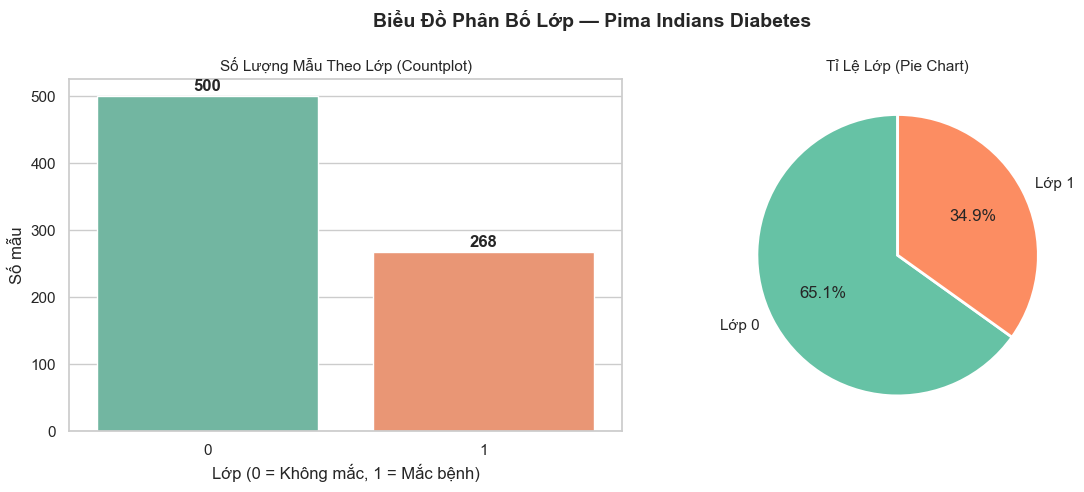

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Biểu Đồ Phân Bố Lớp — Pima Indians Diabetes',
             fontsize=14, fontweight='bold')

# Countplot — số lượng mẫu từng lớp
sns.countplot(data=df, x=TARGET, order=class_counts.index,
              palette='Set2', ax=axes[0])
axes[0].set_title('Số Lượng Mẫu Theo Lớp (Countplot)', fontsize=11)
axes[0].set_xlabel('Lớp (0 = Không mắc, 1 = Mắc bệnh)')
axes[0].set_ylabel('Số mẫu')
for bar, count in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart — tỉ lệ phần trăm từng lớp
axes[1].pie(
    class_counts.values,
    labels=[f'Lớp {x}' for x in class_counts.index],
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('Set2', len(class_counts)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Tỉ Lệ Lớp (Pie Chart)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_class_distribution.png'), bbox_inches='tight')
plt.show()


### 3.2.2. Ma Trận Tương Quan (Correlation Heatmap)

Ma trận tương quan Pearson giữa tất cả đặc trưng và nhãn. Giá trị gần ±1 cho thấy tương quan mạnh — cặp đặc trưng tương quan cao có thể gây đa cộng tuyến với các mô hình tuyến tính. Đặc trưng tương quan mạnh nhất với cột `class` là ứng viên quan trọng nhất cho mô hình phân loại.


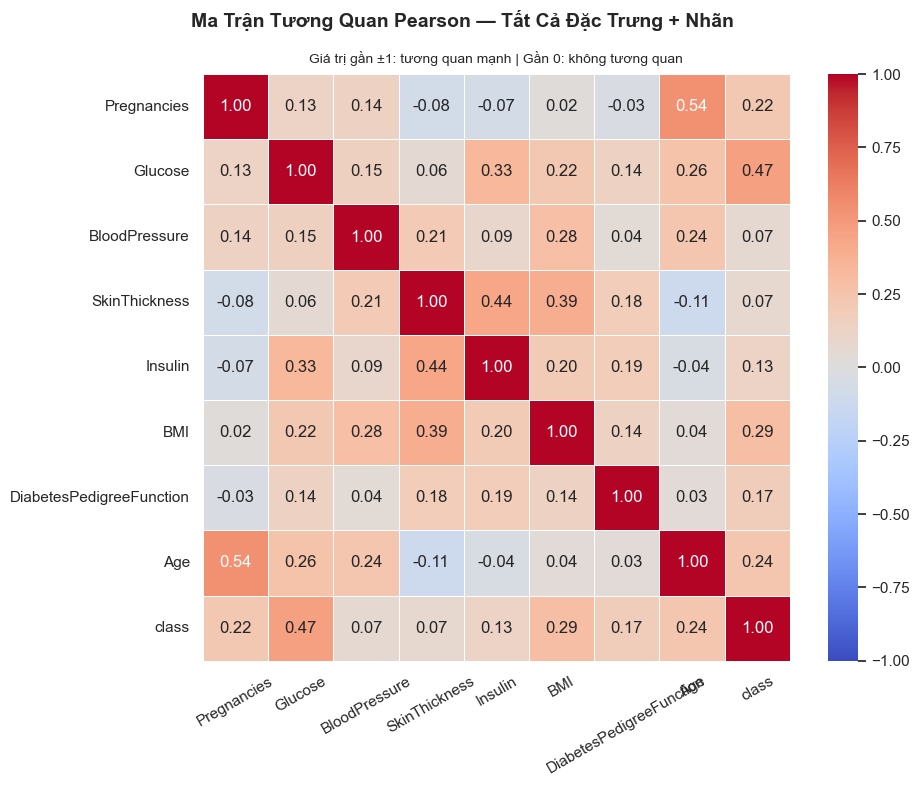

In [4]:
corr = df[FEATURES + [TARGET]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Ma Trận Tương Quan Pearson — Tất Cả Đặc Trưng + Nhãn',
             fontsize=14, fontweight='bold')

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax
)
ax.set_title('Giá trị gần ±1: tương quan mạnh | Gần 0: không tương quan',
             fontsize=10, pad=8)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_correlation_heatmap.png'), bbox_inches='tight')
plt.show()


### 3.2.3. Boxplot Từng Đặc Trưng Theo Lớp

Boxplot phân tách từng đặc trưng theo lớp để quan sát sự khác biệt phân phối giữa nhóm mắc bệnh (lớp 1) và không mắc (lớp 0). Đặc trưng nào có hai hộp ít chồng lấp thì có khả năng phân tách tốt — thường thấy rõ nhất ở Glucose và BMI.


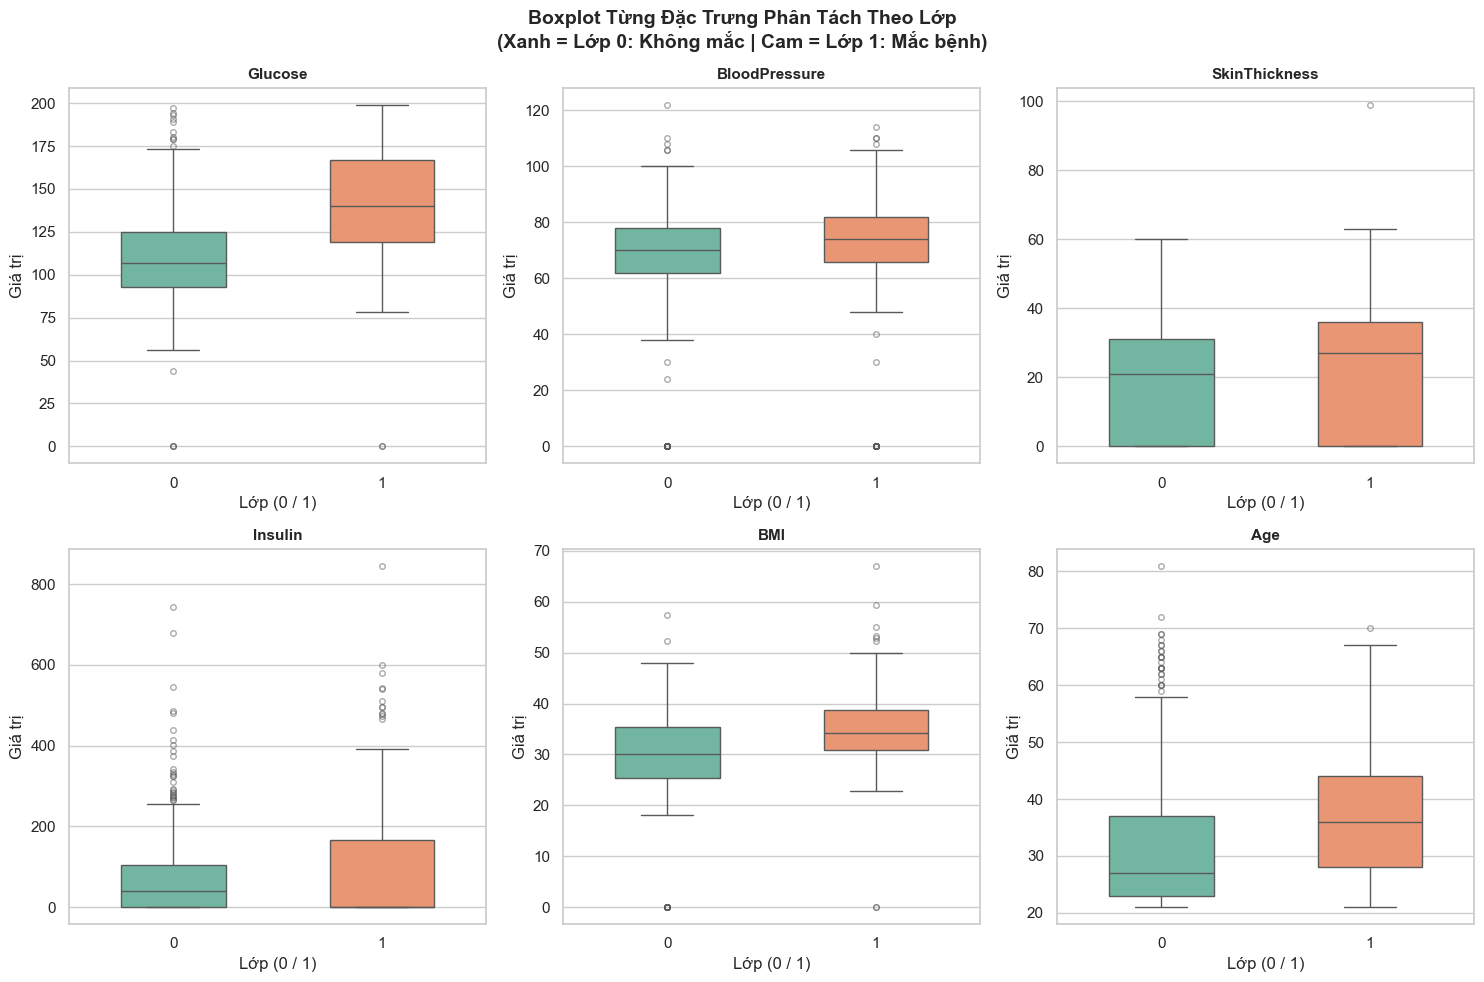

In [5]:
plot_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
ncols = 3
nrows = int(np.ceil(len(plot_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
fig.suptitle('Boxplot Từng Đặc Trưng Phân Tách Theo Lớp\n(Xanh = Lớp 0: Không mắc | Cam = Lớp 1: Mắc bệnh)',
             fontsize=14, fontweight='bold')
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    sns.boxplot(
        data=df, x=TARGET, y=col,
        palette='Set2', ax=axes[i],
        width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Lớp (0 / 1)')
    axes[i].set_ylabel('Giá trị')

for j in range(len(plot_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_boxplot_by_class.png'), bbox_inches='tight')
plt.show()


### 3.2.4. Histogram Phân Phối Từng Đặc Trưng Theo Lớp

Histogram kết hợp KDE cho thấy hình dạng phân phối của từng đặc trưng, phân tách theo lớp:
- Phân phối lệch phải (right-skewed) thường gặp ở Insulin và Pregnancies.
- Vùng giá trị 0 lớn bất thường ở Insulin, SkinThickness phản ánh dữ liệu thiếu được mã hoá thành 0.
- Đặc trưng có hai đường KDE ít chồng lấp sẽ phân biệt lớp tốt hơn.


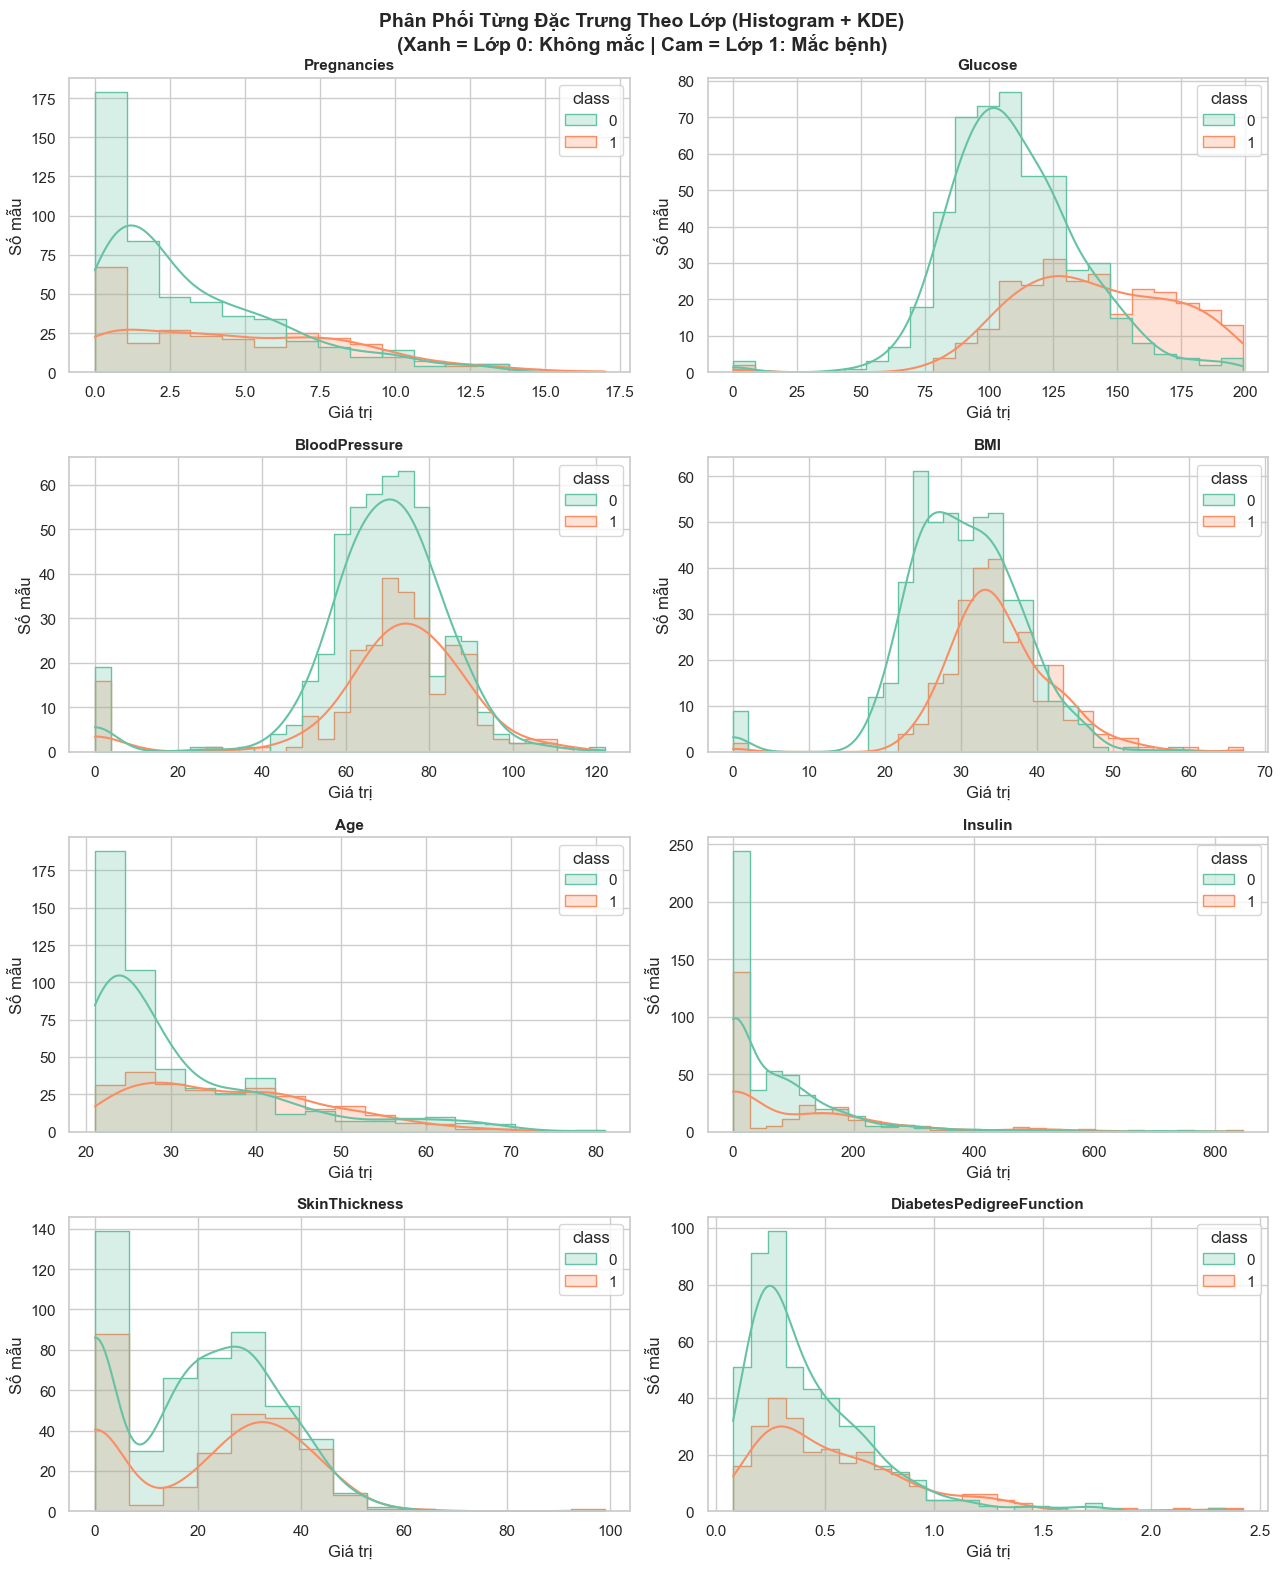

In [6]:
hist_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
             'Age', 'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction']
ncols = 2
nrows = int(np.ceil(len(hist_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
fig.suptitle('Phân Phối Từng Đặc Trưng Theo Lớp (Histogram + KDE)\n(Xanh = Lớp 0: Không mắc | Cam = Lớp 1: Mắc bệnh)',
             fontsize=14, fontweight='bold')
axes = np.array(axes).reshape(-1)

for i, col in enumerate(hist_cols):
    sns.histplot(
        data=df, x=col, hue=TARGET,
        kde=True, element='step',
        palette='Set2', ax=axes[i]
    )
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Giá trị')
    axes[i].set_ylabel('Số mẫu')

for j in range(len(hist_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_histogram_by_class.png'), bbox_inches='tight')
plt.show()


### 3.2.5. Pairplot — Tương Quan Cặp Đặc Trưng Theo Lớp

Pairplot hiển thị scatter plot của tất cả cặp đặc trưng được chọn, phân màu theo lớp. Đường chéo hiển thị histogram phân phối của từng đặc trưng. Cặp đặc trưng nào mà hai lớp tách biệt rõ là gợi ý quan trọng cho bước feature engineering hoặc chọn mô hình.


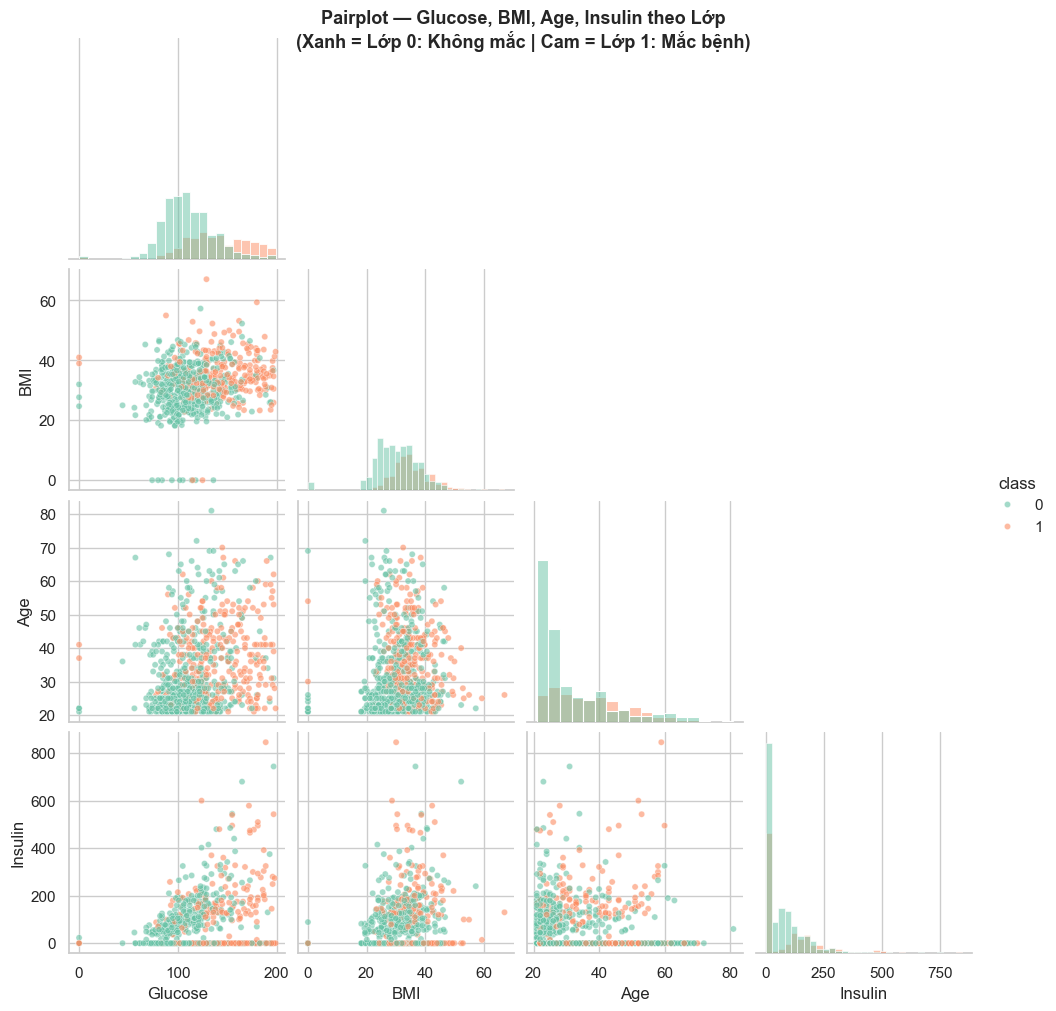

In [7]:
# Chọn 4 đặc trưng có khả năng phân tách lớp cao nhất (dựa trên boxplot và histogram)
pairplot_cols = ['Glucose', 'BMI', 'Age', 'Insulin', TARGET]

g = sns.pairplot(
    df[pairplot_cols], hue=TARGET,
    corner=True, diag_kind='hist',
    palette='Set2',
    plot_kws={'alpha': 0.6, 's': 20}
)
g.figure.suptitle(
    'Pairplot — Glucose, BMI, Age, Insulin theo Lớp\n(Xanh = Lớp 0: Không mắc | Cam = Lớp 1: Mắc bệnh)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig(os.path.join(EXP_DIR, 'plot_pairplot.png'), bbox_inches='tight')
plt.show()


# 4. Chuẩn Bị Dữ Liệu
## 4.1. Kiểm Tra Phân Phối Chuẩn và Chia Train/Test

Kiểm định Shapiro-Wilk cho từng đặc trưng để xác định đặc trưng nào gần phân phối chuẩn (p > 0.05).
Dữ liệu được chia theo tỉ lệ **70/30** với `stratify` để đảm bảo tỉ lệ lớp giống nhau trong cả hai tập.


In [8]:
# Mã hoá nhãn về dạng số nguyên (0/1)
label_encoder = LabelEncoder()
y_encoded = pd.Series(
    label_encoder.fit_transform(df[TARGET]),
    index=df.index, name=TARGET
)
X = df[FEATURES].copy()
y = y_encoded

# Kiểm định Shapiro-Wilk — nếu mẫu > 5000 thì lấy mẫu con để tránh vượt giới hạn
normality_rows = []
for feature in FEATURES:
    sample = df[feature]
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=RANDOM_STATE)
    _, p_value = stats.shapiro(sample)
    normality_rows.append({
        'feature': feature,
        'p_value': round(float(p_value), 4),
        'normal_p_gt_0_05': bool(p_value > 0.05)
    })
display(pd.DataFrame(normality_rows))

# Chia train/test với stratify để giữ nguyên tỉ lệ lớp
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


,feature,p_value,normal_p_gt_0_05
0,Pregnancies,0.0,False
1,Glucose,0.0,False
2,BloodPressure,0.0,False
3,SkinThickness,0.0,False
4,Insulin,0.0,False
5,BMI,0.0,False
6,DiabetesPedigreeFunction,0.0,False
7,Age,0.0,False


Train: (537, 8) | Test: (231, 8)


## 4.2. Chuẩn Hoá Dữ Liệu và Lưu File CSV

Ba phiên bản dữ liệu được tạo để notebook train so sánh hiệu quả từng phương pháp chuẩn hoá:
- **Raw** — dữ liệu gốc, không biến đổi.
- **MinMax** — đưa về khoảng [0, 1]; phù hợp với kNN, SVM.
- **Standard** — chuẩn hoá về mean=0, std=1; phù hợp với Logistic Regression, LDA.

Scaler chỉ `fit` trên tập train rồi `transform` tập test — tránh data leakage.


In [9]:
def save_split(X_tr, X_te, y_tr, y_te, train_path, test_path, scaler=None):
    """Ghép X và y, áp dụng scaler (nếu có) rồi lưu ra CSV.
    Scaler chỉ fit trên X_tr để tránh data leakage sang tập test.
    """
    Xtr = X_tr.copy()
    Xte = X_te.copy()
    if scaler is not None:
        Xtr = pd.DataFrame(
            scaler.fit_transform(X_tr), columns=FEATURES, index=X_tr.index
        )
        Xte = pd.DataFrame(
            scaler.transform(X_te), columns=FEATURES, index=X_te.index
        )
    train_df = pd.concat([Xtr, y_tr], axis=1)
    test_df  = pd.concat([Xte, y_te], axis=1)
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)
    return train_df, test_df

train_raw,      test_raw      = save_split(X_train, X_test, y_train, y_test, TRAIN_RAW,      TEST_RAW)
train_minmax,   test_minmax   = save_split(X_train, X_test, y_train, y_test, TRAIN_MINMAX,   TEST_MINMAX,   MinMaxScaler())
train_standard, test_standard = save_split(X_train, X_test, y_train, y_test, TRAIN_STANDARD, TEST_STANDARD, StandardScaler())

print('Đã lưu 3 cặp train/test vào:', EXP_DIR)


Đã lưu 3 cặp train/test vào: D:\final-project-CSTTNT-\indians-diabetes\exps_\pima_indians_diabetes


## 4.3. So Sánh Phân Phối Trước/Sau Chuẩn Hoá

Histogram của 4 đặc trưng đầu tiên trên cả 3 phiên bản dữ liệu để xác nhận hiệu quả chuẩn hoá.
Mỗi hàng tương ứng một phương pháp chuẩn hoá, mỗi cột là một đặc trưng — nhờ cách bố cục này có thể quan sát ngay sự khác biệt mà không cần nhìn sang biểu đồ khác.


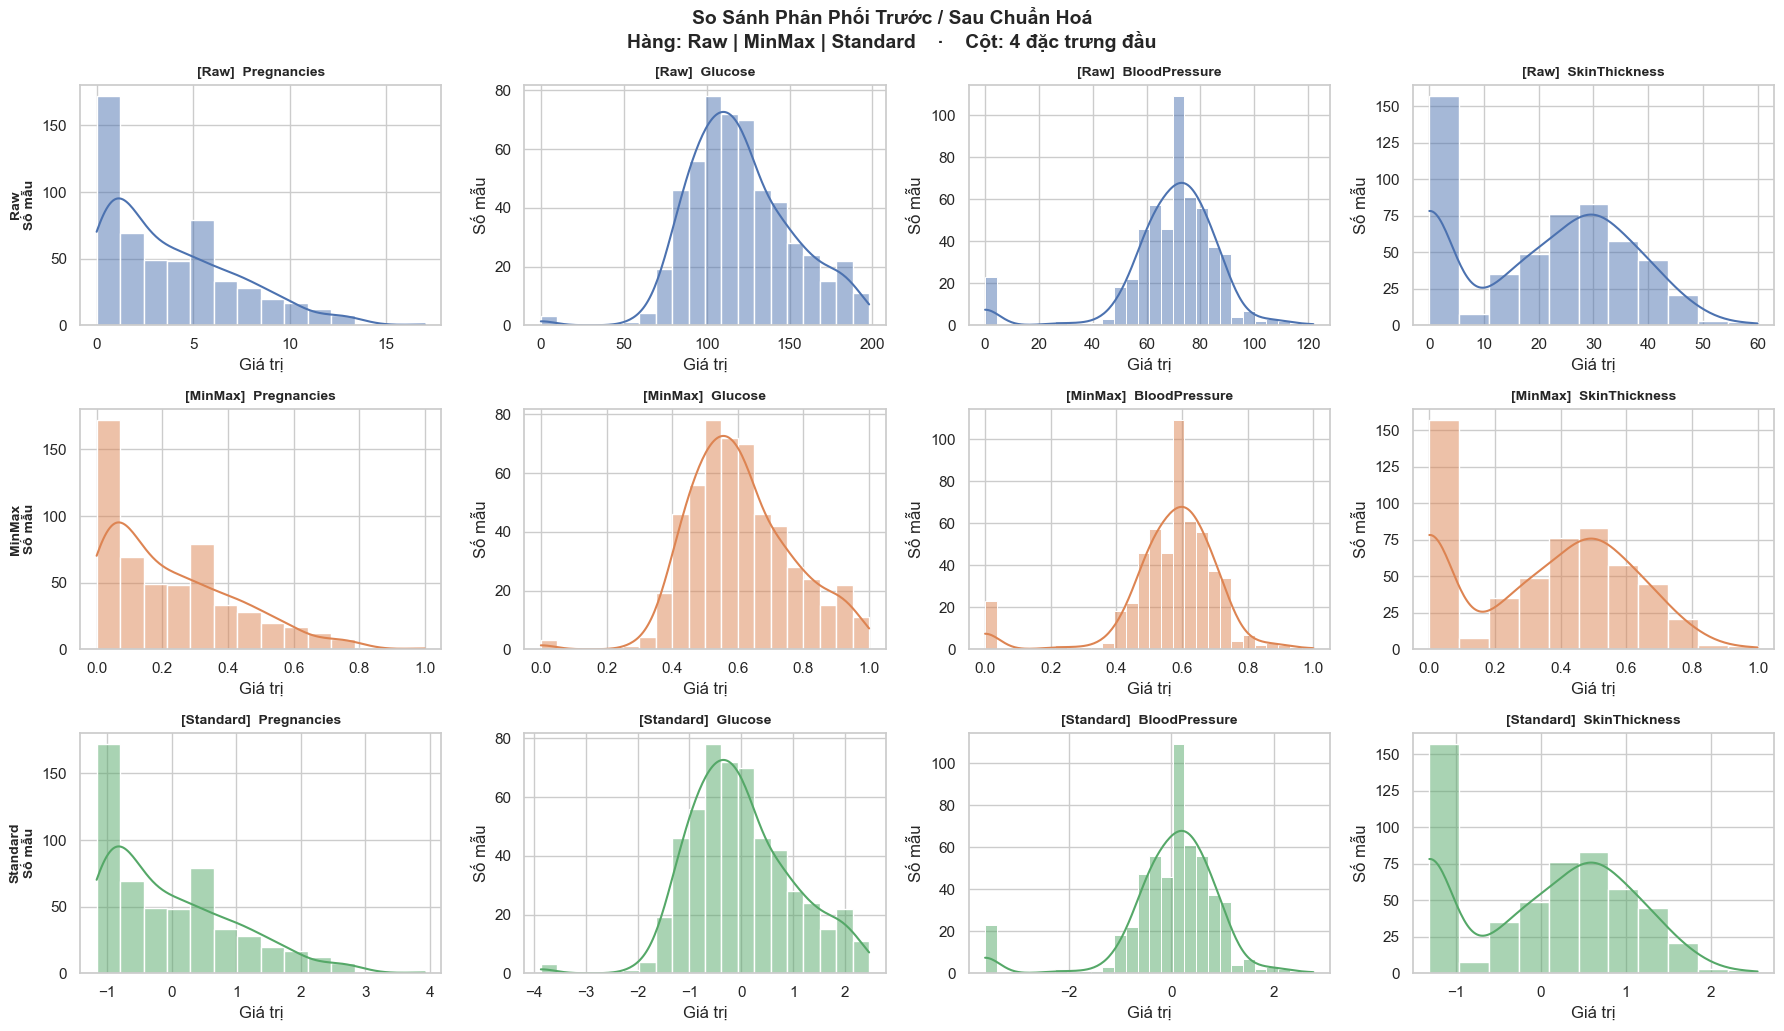

In [10]:
compare_features = FEATURES[:4]
variants = [
    ('Raw',      train_raw,      'C0'),
    ('MinMax',   train_minmax,   'C1'),
    ('Standard', train_standard, 'C2'),
]

fig, axes = plt.subplots(
    len(variants), len(compare_features),
    figsize=(4.5 * len(compare_features), 3.5 * len(variants))
)
fig.suptitle(
    'So Sánh Phân Phối Trước / Sau Chuẩn Hoá\n'
    'Hàng: Raw | MinMax | Standard    ·    Cột: 4 đặc trưng đầu',
    fontsize=14, fontweight='bold'
)
axes = np.array(axes).reshape(len(variants), len(compare_features))

for r, (title, frame, color) in enumerate(variants):
    for c, feature in enumerate(compare_features):
        sns.histplot(frame[feature], kde=True, ax=axes[r, c], color=color)
        axes[r, c].set_title(f'[{title}]  {feature}', fontsize=10, fontweight='bold')
        axes[r, c].set_xlabel('Giá trị')
        axes[r, c].set_ylabel('Số mẫu')
    # Nhãn hàng để phân biệt phương pháp chuẩn hoá
    axes[r, 0].set_ylabel(f'{title}\nSố mẫu', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_scaling_compare.png'), bbox_inches='tight')
plt.show()


# 5. Ghi Kết Quả EDA vào Excel
## 5.1. Ghi Log Thực Nghiệm và Metadata Lần Chia Dữ Liệu

Lưu kết quả EDA ra `eda_log.xlsx` với **5 sheet** theo format chuẩn:
- **Thong_tin_chung** — thời gian chạy, đường dẫn file, số dòng/cột/lớp, tỉ lệ split.
- **Thong_ke_mo_ta** — bảng `describe()` đầy đủ.
- **Missing_Values** — Cột / Số thiếu / % thiếu.
- **Phan_phoi_lop** — Lớp / Số lượng / Tỉ lệ %.
- **Train_Test_Split** — Tập / File path / Số mẫu.


In [11]:
run_end = datetime.now()

# ── Sheet 1: Thong_tin_chung ───────────────────────────────────────────────
thong_tin = pd.DataFrame([
    ['Thời gian chạy', run_end.strftime('%Y-%m-%d %H:%M:%S')],
    ['File dữ liệu',   DATA_PATH],
    ['Số dòng',        len(df)],
    ['Số cột',         df.shape[1]],
    ['Số lớp',         df[TARGET].nunique()],
    ['Missing values', int(df.isnull().sum().sum())],
    ['Duplicates',     int(df.duplicated().sum())],
    ['Tỉ lệ split',    f'Train {int((1-TEST_SIZE)*100)}% / Test {int(TEST_SIZE*100)}%'],
], columns=['Thông tin', 'Giá trị'])

# ── Sheet 2: Thong_ke_mo_ta ───────────────────────────────────────────────
thong_ke = df[FEATURES].describe().round(4)
thong_ke.index.name = 'Thống kê'

# ── Sheet 3: Missing_Values ────────────────────────────────────────────────
missing_sheet = pd.DataFrame({
    'Cột':      df.columns.tolist(),
    'Số thiếu': df.isnull().sum().values,
    '% thiếu':  (df.isnull().sum() / len(df) * 100).round(2).values,
})

# ── Sheet 4: Phan_phoi_lop ─────────────────────────────────────────────────
phan_phoi = pd.DataFrame({
    'Lớp':     class_counts.index.tolist(),
    'Số lượng': class_counts.values,
    'Tỉ lệ %': (class_counts.values / len(df) * 100).round(2),
})

# ── Sheet 5: Train_Test_Split ──────────────────────────────────────────────
split_sheet = pd.DataFrame([
    ['Train (raw)',      TRAIN_RAW,      len(train_raw)],
    ['Test (raw)',       TEST_RAW,       len(test_raw)],
    ['Train (minmax)',   TRAIN_MINMAX,   len(train_minmax)],
    ['Test (minmax)',    TEST_MINMAX,    len(test_minmax)],
    ['Train (standard)', TRAIN_STANDARD, len(train_standard)],
    ['Test (standard)',  TEST_STANDARD,  len(test_standard)],
], columns=['Tập', 'File', 'Số mẫu'])

# Lưu metadata JSON
split_meta = {
    'dataset':      DATA_FILE,
    'created_at':   run_end.strftime('%Y-%m-%d %H:%M:%S'),
    'features':     FEATURES,
    'classes':      [int(c) for c in label_encoder.classes_],
    'train_rows':   int(len(train_raw)),
    'test_rows':    int(len(test_raw)),
    'random_state': RANDOM_STATE,
    'test_size':    TEST_SIZE,
}
with open(SPLIT_META, 'w', encoding='utf-8') as f:
    json.dump(split_meta, f, indent=2, ensure_ascii=False)

with pd.ExcelWriter(EDA_LOG, engine='openpyxl', mode='w') as writer:
    thong_tin.to_excel(writer,  sheet_name='Thong_tin_chung', index=False)
    thong_ke.to_excel(writer,   sheet_name='Thong_ke_mo_ta')
    missing_sheet.to_excel(writer, sheet_name='Missing_Values', index=False)
    phan_phoi.to_excel(writer,  sheet_name='Phan_phoi_lop',   index=False)
    split_sheet.to_excel(writer, sheet_name='Train_Test_Split', index=False)

print('=' * 70)
print('TỔNG KẾT EDA — PIMA INDIANS DIABETES')
print('Thời gian  :', run_end.strftime('%Y-%m-%d %H:%M:%S'))
print('Thư mục    :', EXP_DIR)
print('EDA log    :', EDA_LOG)
print('Bước tiếp theo: chạy 02_train.ipynb')
print('=' * 70)


TỔNG KẾT EDA — PIMA INDIANS DIABETES
Thời gian  : 2026-04-03 13:31:44
Thư mục    : D:\final-project-CSTTNT-\indians-diabetes\exps_\pima_indians_diabetes
EDA log    : D:\final-project-CSTTNT-\indians-diabetes\exps_\pima_indians_diabetes\eda_log.xlsx
Bước tiếp theo: chạy 02_train.ipynb
